In [1]:
# 忽略警告訊息
import warnings
warnings.filterwarnings("ignore")

# 匯入必要的套件
import matplotlib.pyplot as plt

# 使用 fivethirtyeight 風格，讓圖表更美觀
# plt.style.use('fivethirtyeight')

# 設定字型，確保中文能正常顯示
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei",
    "Microsoft YaHei",
    "SimHei",
    "Arial Unicode MS",
    "DejaVu Sans"
]

# 設定數學字型，確保負號能正常顯示
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["mathtext.fontset"] = "dejavusans"

# Module 6：集成學習

## 資料集欄位說明

| 欄位 | 說明 |
|---|---|
| `Number` | 寶可夢編號 |
| `Name` | 寶可夢名稱 |
| `Type1` | 第一屬性 |
| `Type2` | 第二屬性，部分寶可夢沒有第二屬性 |
| `HP` | 生命值 |
| `Attack` | 物理攻擊 |
| `Defense` | 物理防禦 |
| `SpecialAtk` | 特殊攻擊 |
| `SpecialDef` | 特殊防禦 |
| `Speed` | 速度 |
| `Generation` | 世代 |
| `Legendary` | 是否為傳奇寶可夢，本章主要作為分類目標 |

本章會示範：

1. Bagging：用多個模型投票或平均。
2. Random Forest：以多棵決策樹進行集成。
3. Boosting / AdaBoost：讓後面的弱學習器修正前面模型的錯誤。
4. Stacking：把多個基礎模型的輸出交給元學習器整合。


In [2]:
# ============================================================
# 1. 讀取資料與初步檢視
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("ex6.csv")

print("資料筆數與欄位數：")
print(data.shape)

print("前 5 筆資料：")
display(data.head())

print("數值型欄位的基本統計摘要：")
display(data.describe())

print("分類目標 Legendary 的類別分布：")
display(data["Legendary"].value_counts())

資料筆數與欄位數：
(894, 12)
前 5 筆資料：


,Number,Name,Type1,Type2,HP,Attack,Defense,SpecialAtk,SpecialDef,Speed,Generation,Legendary
0,1,妙蛙種子,Grass,Poison,45,49,49,65,65,45,1,False
1,2,妙蛙草,Grass,Poison,60,62,63,80,80,60,1,False
2,3,妙蛙花,Grass,Poison,80,82,83,100,100,80,1,False
3,3,妙蛙花Mega,Grass,Poison,80,100,123,122,120,80,1,False
4,4,小火龍,Fire,NaN,39,52,43,60,50,65,1,False


數值型欄位的基本統計摘要：


,Number,HP,Attack,Defense,SpecialAtk,SpecialDef,Speed,Generation
count,894.000000,894.000000,894.000000,894.000000,894.000000,894.000000,894.000000,894.000000
mean,405.083893,69.469799,79.848993,74.420582,73.428412,72.401566,68.241611,3.710291
std,232.652577,25.670988,32.691003,31.323902,33.110134,27.963359,29.283795,1.934529
min,1.000000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.000000
25%,208.000000,50.000000,55.000000,50.000000,50.000000,50.000000,45.000000,2.000000
50%,401.500000,66.000000,75.000000,70.000000,65.000000,70.000000,65.000000,4.000000
75%,608.750000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.000000
max,807.000000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,7.000000


分類目標 Legendary 的類別分布：


Legendary
False    815
True      79
Name: count, dtype: int64

## 1. 準備集成學習用資料

本章主要使用 `Legendary` 作為分類目標：

- `False`：不是傳奇寶可夢
- `True`：是傳奇寶可夢


In [3]:
# ============================================================
# 1. 準備分類與迴歸資料
# ============================================================

from sklearn.model_selection import train_test_split

work = data.copy()

# ------------------------------------------------------------
# 分類任務：根據 6 個能力值預測是否為 Legendary
# ------------------------------------------------------------
features = ["HP", "Attack", "Defense", "SpecialAtk", "SpecialDef", "Speed"]

X = work[features]
y = work["Legendary"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=0
)

print("分類任務的訓練資料形狀：")
print(X_train.shape)

print("分類任務的測試資料形狀：")
print(X_test.shape)

print("訓練資料中的類別分布：")
display(y_train.value_counts().sort_index())

# 欄位順序必須和 features 相同：
# ["HP", "Attack", "Defense", "SpecialAtk", "SpecialDef", "Speed"]
newData = [
    [50, 55, 45, 60, 50, 60],
    [250, 250, 250, 250, 250, 250]
]

# ------------------------------------------------------------
# 迴歸任務：用其他能力值預測 Attack
# ------------------------------------------------------------
reg_features = ["HP", "Defense", "SpecialAtk", "SpecialDef", "Speed"]
X_reg = work[reg_features]
y_reg = work["Attack"]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=0
)

print("迴歸任務的訓練資料形狀：")
print(X_reg_train.shape)


分類任務的訓練資料形狀：
(715, 6)
分類任務的測試資料形狀：
(179, 6)
訓練資料中的類別分布：


Legendary
0    652
1     63
Name: count, dtype: int64

迴歸任務的訓練資料形狀：
(715, 5)


## 2. Bagging：Bootstrap 抽樣與投票整合

Bagging 是 Bootstrap Aggregating 的縮寫。

核心想法：

1. 從原始訓練資料中進行多次「有放回抽樣」。
2. 每一份抽樣資料訓練一個基礎模型。
3. 分類問題使用多數決，迴歸問題使用平均數。

在這個 cell 中，我們先示範 Bootstrap 抽樣，再用 `BaggingClassifier` 建立多棵決策樹進行分類。


In [4]:
# ============================================================
# 2. Bagging 分類：Bootstrap 抽樣與多數決
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 示範 bootstrap：有放回抽樣，因此同一筆資料可能被抽到多次。
print("Bootstrap 抽樣範例：")
bootstrap_sample = X_train.sample(
    n=10, # 抽樣 10 筆資料
    replace=True, # 代表有放回抽樣
    random_state=0
)
display(bootstrap_sample)

# 建立 BaggingClassifier，使用 DecisionTreeClassifier 作為 base 學習器
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=4, random_state=0),
    n_estimators=30,
    max_samples=0.8,
    bootstrap=True,
    random_state=0,
    n_jobs=1
)
bagging_clf.fit(X_train, y_train)
bagging_pred = bagging_clf.predict(X_test)
bagging_accuracy = accuracy_score(y_test, bagging_pred)

print("BaggingClassifier 測試資料 Accuracy：")
print(round(bagging_accuracy, 4))

print("混淆矩陣：")
conf_matrix = pd.DataFrame(
    confusion_matrix(y_test, bagging_pred), 
    index=["真實 0", "真實 1"], 
    columns=["預測 0", "預測 1"]
)
display(conf_matrix)

print("Classification report：")
print(classification_report(y_test, bagging_pred, zero_division=0))

print("新資料的 Bagging 分類預測結果：")
newData_bagging_pred = bagging_clf.predict(newData)
print(newData_bagging_pred)

Bootstrap 抽樣範例：


,HP,Attack,Defense,SpecialAtk,SpecialDef,Speed
356,60,25,35,70,80,60
793,126,131,95,131,98,99
204,75,55,70,55,95,110
576,76,25,45,67,55,24
698,85,60,65,135,105,100
798,80,160,60,170,130,80
657,70,77,60,97,60,108
518,75,95,67,125,95,83
385,44,75,35,63,33,45
114,50,120,53,35,110,87


BaggingClassifier 測試資料 Accuracy：
0.933
混淆矩陣：


,預測 0,預測 1
真實 0,161,2
真實 1,10,6


Classification report：
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       163
           1       0.75      0.38      0.50        16

    accuracy                           0.93       179
   macro avg       0.85      0.68      0.73       179
weighted avg       0.92      0.93      0.92       179

新資料的 Bagging 分類預測結果：
[0 1]


## 3. BaggingRegressor：迴歸問題使用平均數

在分類問題中，Bagging 通常使用多數決。

在迴歸問題中，Bagging 通常把多個基礎模型的預測值取平均。

這裡用 `BaggingRegressor` 示範：

- 基礎模型：決策樹迴歸器
- 任務：用其他能力值預測 `Attack`
- 整合方式：多棵樹的預測結果取平均


In [5]:
# ============================================================
# 3. Bagging 迴歸：多個模型預測值取平均
# ============================================================

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

bagging_reg = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=4, random_state=0),
    n_estimators=30,
    max_samples=0.8,
    bootstrap=True,
    random_state=0,
    n_jobs=1
)

bagging_reg.fit(X_reg_train, y_reg_train)

reg_pred = bagging_reg.predict(X_reg_test)

reg_mse = mean_squared_error(y_reg_test, reg_pred)
reg_rmse = np.sqrt(reg_mse)
reg_mae = mean_absolute_error(y_reg_test, reg_pred)
reg_r2 = r2_score(y_reg_test, reg_pred)

print("BaggingRegressor 迴歸評估：")
print("MAE：", round(reg_mae, 4))
print("RMSE：", round(reg_rmse, 4))
print("R²：", round(reg_r2, 4))

# 用第一筆測試資料觀察多棵樹如何平均。
# 注意：BaggingRegressor 的每棵樹都會對同一筆資料給出一個預測值。
one_sample = X_reg_test.iloc[[0]]
first_tree_pred = bagging_reg.estimators_[0].predict(one_sample)
second_tree_pred = bagging_reg.estimators_[1].predict(one_sample)
third_tree_pred = bagging_reg.estimators_[2].predict(one_sample)
final_pred = bagging_reg.predict(one_sample)

average_demo = pd.DataFrame({
    "來源": ["第 1 棵樹", "第 2 棵樹", "第 3 棵樹", "全部樹平均"],
    "預測 Attack": [first_tree_pred[0], second_tree_pred[0], third_tree_pred[0], final_pred[0]]
})

print("同一筆資料在不同樹上的預測，以及最後平均結果：")
display(average_demo)

BaggingRegressor 迴歸評估：
MAE： 17.8443
RMSE： 23.1369
R²： 0.4857
同一筆資料在不同樹上的預測，以及最後平均結果：


,來源,預測 Attack
0,第 1 棵樹,127.446809
1,第 2 棵樹,98.929825
2,第 3 棵樹,127.166667
3,全部樹平均,115.353230


## 4. K-fold Cross Validation：檢視每個 fold 的訓練結果

交叉驗證可以幫助我們確認模型表現是否穩定。

這裡使用 `StratifiedKFold`，讓每個 fold 盡量維持相近的類別比例。每一個 fold 都會重新訓練一個簡單的 Bagging 模型，並顯示訓練與驗證 accuracy。


In [6]:
# ============================================================
# 4. K-fold Cross Validation：逐一檢視每個 fold 的結果
# ============================================================

from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=0
)

fold_rows = []

for fold, result in enumerate(skf.split(X, y), start=1):
    train_index = result[0]
    valid_index = result[1]

    X_fold_train = X.iloc[train_index]
    X_fold_valid = X.iloc[valid_index]
    y_fold_train = y.iloc[train_index]
    y_fold_valid = y.iloc[valid_index]

    fold_model = BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=4, random_state=0),
        n_estimators=30,
        max_samples=0.8,
        bootstrap=True,
        random_state=0,
        n_jobs=1
    )

    fold_model.fit(X_fold_train, y_fold_train)

    train_pred = fold_model.predict(X_fold_train)
    valid_pred = fold_model.predict(X_fold_valid)

    train_accuracy = accuracy_score(y_fold_train, train_pred)
    valid_accuracy = accuracy_score(y_fold_valid, valid_pred)

    fold_rows.append({
        "fold": fold,
        "train_samples": len(train_index),
        "valid_samples": len(valid_index),
        "train_accuracy": train_accuracy,
        "valid_accuracy": valid_accuracy
    })

fold_result = pd.DataFrame(fold_rows)

print("每個 fold 的訓練與驗證結果：")
display(fold_result)

每個 fold 的訓練與驗證結果：


,fold,train_samples,valid_samples,train_accuracy,valid_accuracy
0,1,715,179,0.955245,0.944134
1,2,715,179,0.966434,0.938547
2,3,715,179,0.963636,0.921788
3,4,715,179,0.959441,0.944134
4,5,716,178,0.963687,0.938202


## 5. Random Forest：隨機森林

Random Forest 是 Bagging 的代表方法之一。它同時使用兩種隨機性：

1. 對訓練樣本做 Bootstrap 抽樣。
2. 每次節點分裂時，只從部分特徵中尋找最佳分裂。

因此，不同決策樹會學到不同規則，最後再透過投票整合。


In [7]:
# ============================================================
# 5. Random Forest：多棵決策樹投票
# ============================================================

from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    max_features="sqrt",
    bootstrap=True,
    random_state=0,
    n_jobs=1
)

random_forest.fit(X_train, y_train)
rf_pred = random_forest.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("RandomForestClassifier 測試資料 Accuracy：")
print(round(rf_accuracy, 4))

print("混淆矩陣：")
conf_matrix = pd.DataFrame(
    confusion_matrix(y_test, rf_pred), 
    index=["真實 0", "真實 1"], 
    columns=["預測 0", "預測 1"]
)
display(conf_matrix)

print("Classification report：")
print(classification_report(y_test, rf_pred, zero_division=0))

print("新資料的 Random Forest 分類預測結果：")
newData_rf_pred = random_forest.predict(newData)
print(newData_rf_pred)

print("Random Forest 特徵重要性：")
rf_importance = pd.DataFrame({
    "feature": features,
    "importance": random_forest.feature_importances_
})
rf_importance = rf_importance.sort_values("importance", ascending=False)
display(rf_importance)

RandomForestClassifier 測試資料 Accuracy：
0.9274
混淆矩陣：


,預測 0,預測 1
真實 0,160,3
真實 1,10,6


Classification report：
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       163
           1       0.67      0.38      0.48        16

    accuracy                           0.93       179
   macro avg       0.80      0.68      0.72       179
weighted avg       0.92      0.93      0.92       179

新資料的 Random Forest 分類預測結果：
[0 1]
Random Forest 特徵重要性：


,feature,importance
3,SpecialAtk,0.262616
5,Speed,0.186758
4,SpecialDef,0.160181
1,Attack,0.147707
0,HP,0.146557
2,Defense,0.096180


## 6. 隨機森林特徵重要性視覺化

隨機森林可以計算特徵重要性。若某個特徵經常被用來有效分裂節點，通常會得到較高的重要性。

下方使用 `matplotlib` 畫出各能力值特徵的重要性。


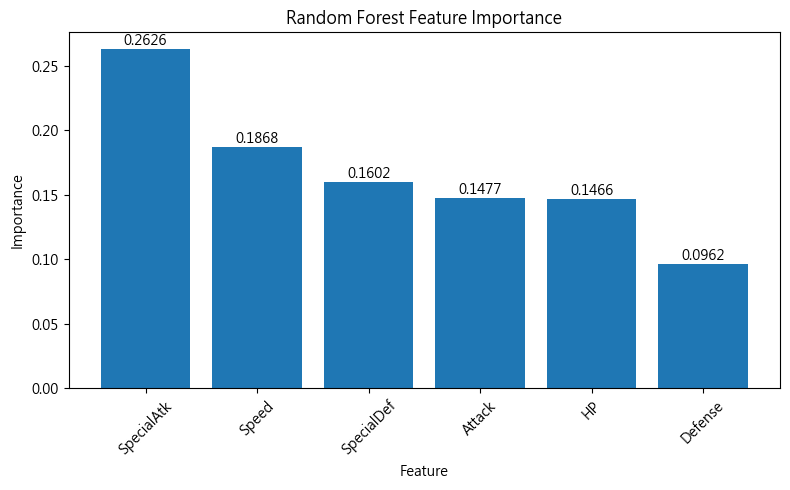

In [8]:
plt.figure(figsize=(8,5))
plt.bar(rf_importance["feature"], rf_importance["importance"])
plt.title("Random Forest Feature Importance")

for i, imp in enumerate(rf_importance["importance"]):
    plt.text(i, imp, f"{imp:.4f}", ha="center", va="bottom")

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Boosting 與 AdaBoost

Boosting 是循序式集成方法。

它和 Bagging 不同：

- Bagging 的模型大多可以平行訓練。
- Boosting 的模型通常一個接著一個訓練。
- 後面的模型會更重視前面模型預測錯誤的樣本。

AdaBoost 常搭配很簡單的弱學習器，例如深度為 1 的決策樹，也稱為 decision stump。


In [9]:
# ============================================================
# 7. AdaBoost：用弱學習器逐步修正錯誤
# ============================================================

from sklearn.ensemble import AdaBoostClassifier

weak_tree = DecisionTreeClassifier(
    max_depth=1,
    random_state=0
)

adaboost = AdaBoostClassifier(
    estimator=weak_tree,
    n_estimators=80,
    learning_rate=0.5,
    random_state=0
)

adaboost.fit(X_train, y_train)
ada_pred = adaboost.predict(X_test)
ada_accuracy = accuracy_score(y_test, ada_pred)

print("AdaBoostClassifier 測試資料 Accuracy：")
print(round(ada_accuracy, 4))

print("混淆矩陣：")
ada_confusion = pd.DataFrame(confusion_matrix(y_test, ada_pred), index=["真實 0", "真實 1"], columns=["預測 0", "預測 1"])
display(ada_confusion)

print("Classification report：")
print(classification_report(y_test, ada_pred, zero_division=0))

print("新資料的 AdaBoost 分類預測結果：")
newData_ada_pred = adaboost.predict(newData)
print(newData_ada_pred)

AdaBoostClassifier 測試資料 Accuracy：
0.9106
混淆矩陣：


,預測 0,預測 1
真實 0,157,6
真實 1,10,6


Classification report：
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       163
           1       0.50      0.38      0.43        16

    accuracy                           0.91       179
   macro avg       0.72      0.67      0.69       179
weighted avg       0.90      0.91      0.90       179

新資料的 AdaBoost 分類預測結果：
[0 1]


## 8. Stacking：堆疊法

Stacking 會分成兩層：

1. 第一層：多個基礎模型各自做預測。
2. 第二層：元學習器學習如何整合第一層模型的預測。

在這個範例中：

- 基礎模型：Decision Tree、Random Forest、Gaussian Naive Bayes
- 元學習器：Logistic Regression

`StackingClassifier` 內部會用交叉驗證產生第一層模型的訓練預測，避免元學習器直接看到過度樂觀的結果。


In [10]:
# ============================================================
# 8. Stacking：基礎模型 + 元學習器
# ============================================================

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier

base_tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=0
)

base_forest = RandomForestClassifier(
    n_estimators=80,
    max_depth=5,
    max_features="sqrt",
    random_state=0,
    n_jobs=1
)

base_nb = GaussianNB()

meta_model = LogisticRegression(
    max_iter=1000,
    random_state=0
)

stacking = StackingClassifier(
    estimators=[
        ("tree", base_tree),
        ("forest", base_forest),
        ("nb", base_nb)
    ],
    final_estimator=meta_model,
    cv=5,
    n_jobs=1
)

stacking.fit(X_train, y_train)
stack_pred = stacking.predict(X_test)
stack_accuracy = accuracy_score(y_test, stack_pred)

print("StackingClassifier 測試資料 Accuracy：")
print(round(stack_accuracy, 4))

print("混淆矩陣：")
stack_confusion = pd.DataFrame(
    confusion_matrix(y_test, stack_pred), 
    index=["真實 0", "真實 1"], 
    columns=["預測 0", "預測 1"]
)
display(stack_confusion)

print("Classification report：")
print(classification_report(y_test, stack_pred, zero_division=0))

print("新資料的 Stacking 分類預測結果：")
newData_stack_pred = stacking.predict(newData)
print(newData_stack_pred)

StackingClassifier 測試資料 Accuracy：
0.9274
混淆矩陣：


,預測 0,預測 1
真實 0,159,4
真實 1,9,7


Classification report：
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       163
           1       0.64      0.44      0.52        16

    accuracy                           0.93       179
   macro avg       0.79      0.71      0.74       179
weighted avg       0.92      0.93      0.92       179

新資料的 Stacking 分類預測結果：
[0 1]


## 9. 整體比較

最後把本章示範的幾種集成分類模型放在一起比較：

- Bagging
- Random Forest
- AdaBoost
- Stacking

這個圖只比較測試資料的 accuracy。實務上若類別不平衡，還需要同時看 precision、recall、F1-score 與混淆矩陣。


不同集成模型的測試資料 Accuracy：


,model,accuracy
0,Bagging,0.932961
1,Random Forest,0.927374
2,AdaBoost,0.910615
3,Stacking,0.927374


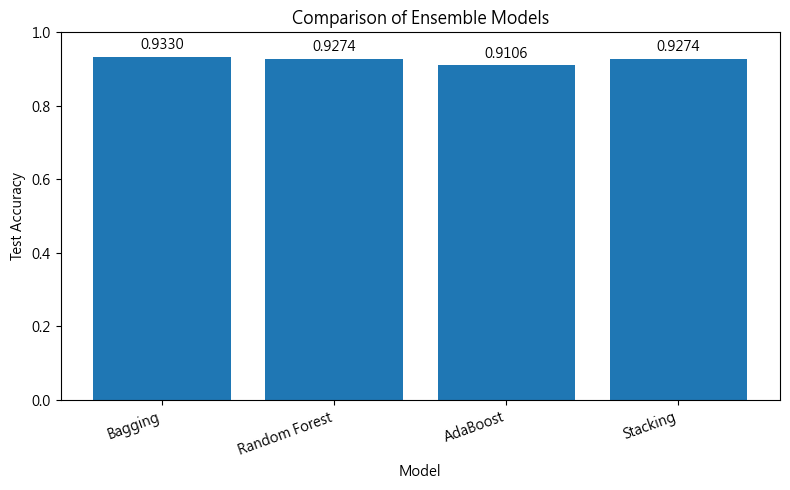

In [11]:
# ============================================================
# 9. 視覺化：比較不同集成模型的測試 Accuracy
# ============================================================

score_table = pd.DataFrame({
    "model": ["Bagging", "Random Forest", "AdaBoost", "Stacking"],
    "accuracy": [bagging_accuracy, rf_accuracy, ada_accuracy, stack_accuracy]
})

print("不同集成模型的測試資料 Accuracy：")
display(score_table)

plt.figure(figsize=(8, 5))
plt.bar(score_table["model"], score_table["accuracy"])
plt.ylim(0, 1)
plt.title("Comparison of Ensemble Models")

# 在每個柱狀圖上方顯示準確率數值，格式為小數點後 4 位。
for index, row in score_table.iterrows():
    plt.text(index, row["accuracy"] + 0.01, f"{row['accuracy']:.4f}", ha="center", va="bottom")

plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()